# Bria 3.2: Fine-tuning and Inference Tutorial

## Introduction

Welcome to this tutorial on using Bria 3.2 is the next-generation commercial-ready text-to-image model.. This notebook will guide you through:

1. Setting up the environment
2. Installing Bria 3.2 and its dependencies
3. Preparing your data for fine-tuning
4. Training a LoRA (Low-Rank Adaptation) model on your custom data
5. Generating images using your fine-tuned model

Bria 3.2 is particularly noteworthy because it's built with commercial use in mind. The model is trained on 100% licensed data and comes with legal liability coverage for copyright and privacy infringements, making it suitable for business applications.

### Key Features of Bria 3.2

- **Legally Compliant**: Trained on fully licensed data with liability coverage
- **Excellent Fine-tuning Capabilities**: Designed to maintain style while preserving prompt alignment
- **Enterprise-Ready**: Built for commercial applications
- **Customizable**: Access to source code and weights for extensive customization

Let's get started with setting up our environment and exploring Bria 3.2's capabilities!

## Environment Setup

First, let's install the required dependencies. Bria 3.2 requires specific packages to function properly.

In [1]:
# Install required dependencies
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
!pip install transformers
!pip install protobuf
!pip install sentencepiece
!pip install accelerate
!pip install peft
!pip install prodigyopt
!pip install datasets
!pip install git+https://github.com/galbria/diffusers.git@bria_3_2_pipeline
!pip install huggingface_hub
!pip install accelerate


Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu121

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: /usr/bin/python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: /usr/bin/python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: /usr/bin/python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: /usr/bin/python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new rel

## Downloading Bria 3.2 Files

Next, we need to download the necessary files from the Hugging Face Hub. These files include the pipeline, transformer, and utility scripts that we'll need to run the model.

In [ ]:
# from huggingface_hub import hf_hub_download
# import os

# try:
#     local_dir = os.path.dirname(__file__)
# except:
#     local_dir = '.'
    
# # Download pipeline and utility files
# hf_hub_download(repo_id="briaai/BRIA-3.2",revision="pre_diffusers_support", filename='pipeline_bria.py', local_dir=local_dir)
# hf_hub_download(repo_id="briaai/BRIA-3.2",revision="pre_diffusers_support", filename='transformer_bria.py', local_dir=local_dir)
# hf_hub_download(repo_id="briaai/BRIA-3.2",revision="pre_diffusers_support", filename='bria_utils.py', local_dir=local_dir)


# print("Successfully downloaded Bria 3.2 files")

## Fine-tuning Bria 3.2 with LoRA

### What is LoRA?

LoRA (Low-Rank Adaptation) is a technique that allows efficient fine-tuning of large models by adding trainable low-rank matrices to the existing weights rather than modifying all the parameters. This makes fine-tuning faster and more resource-efficient.

### Preparing Your Data

Before we can fine-tune the model, we need to prepare our data. Here are the guidelines for preparing your dataset:

1. **Image Collection**: Gather 5-20 high-quality images of the subject/style you want to teach the model
2. **Image Resolution**: Images should be at least 1M pixels (eg 1024x1024) pixels or similar resolution
3. **Image Variety**: Use images that maintain consistency in the visual element you want the model to learn, but with enough variety for the model to generalize
4. **Captions**: Create captions that describe each image's content. It's advisable to use either:
   - A constant description (e.g., "An illustration of a cute brown bear")
   - A unique "trigger word" (e.g., "a character named Briabear")
5. **Caption Length**: Keep captions under 128 tokens (approximately 100 words)

Let's create a directory for our training data and download an example dataset:

In [ ]:
#TODO: Change the directory name to your own
# Create a directory for the training data
!mkdir -p example_finetune_data

# If you have your own data, you should organize it in the following structure:
# example_finetune_data/
# ├── image1.jpg
# ├── image2.jpg
# └── metadata.csv
#
# Where metadata.csv contains: file_name,text
# image1.jpg,An illustration of a character named Briabear
# image2.jpg,A cute brown bear wearing a purple bowtie

# For the purposes of this tutorial, let's download example data from the Bria 3.2 repository
# Note: In a real scenario, you would prepare your own custom dataset

# You could use something like this to download example data if available:
# !wget https://huggingface.co/briaai/Bria 3.2/resolve/main/example_finetune_data.zip
# !unzip example_finetune_data.zip

print("Set up your training data directory. Please add your images and metadata.csv to the example_finetune_data folder.")

### Training the LoRA Model

Now that we have our data ready, let's train a LoRA model on top of Bria 3.2. You can adjust the hyperparameters based on your specific use case:

- **rank**: Controls the complexity of the adaptation. Default is 128, but lower ranks can suffice for simple use cases.
- **max_train_steps**: How many steps the model will train for. Consider training for more steps and evaluating different checkpoints.
- **train_batch_size**: Batch size for training. Depends on your GPU memory.
- **gradient_accumulation_steps**: Accumulates gradients before updating weights. Useful when you can't increase batch size.

Let's start the training process:

In [15]:
# Create a directory for the output
!mkdir -p example_output_lora

# Run the training script
# Note: This will take some time depending on your GPU
!python Finetune-Bria-3.2-LoRa/train_lora.py \
    --pretrained_model_name_or_path briaai/BRIA-3.2 \
    --dataset_name /home/ubuntu/cookbooks/dataset/ \
    --output_dir example_output_lora/ \
    --max_train_steps 2000  \
    --rank 128 \
    --train_batch_size 1 \
    --gradient_accumulation_steps 4 \
    --max_sequence_length 128 \
    --image_column image \
    --caption_column text \
    --resolution 1024 \
    --gradient_checkpointing
    

12719.01s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
12724.32s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


/home/ubuntu/cookbooks/.venv/lib/python3.11/site-packages/accelerate/accelerator.py:516: UserWarning: `log_with=tensorboard` was passed but no supported trackers are currently installed.
  warnings.warn(f"`log_with={log_with}` was passed but no supported trackers are currently installed.")
08/03/2025 13:02:20 - INFO - __main__ - Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: bf16

{'stochastic_sampling'} was not found in config. Values will be initialized to default values.
All model checkpoint weights were used when initializing BriaTransformer2DModel.

All the weights of BriaTransformer2DModel were initialized from the model checkpoint at briaai/BRIA-3.2.
If your task is similar to the task the model of the checkpoint was trained on, you can already use BriaTransformer2DModel for predictions without further training.
You set `add_prefix_space`. The tokenizer needs to be converted from the slow t

## Advanced Training Tips

Here are some additional tips to get the best results from your fine-tuning:

1. **Experiment with the rank parameter**: 
   - Start with a lower rank (e.g., 64) for simple concepts
   - Use higher ranks (128 or more) to teach the model finer details

2. **Training duration**:
   - Train for different numbers of steps and compare results
   - Save checkpoints during training to find the optimal stopping point

3. **Learning rate**:
   - The default optimizer is "prodigy" with a learning rate of 1
   - You can experiment with different optimizers and learning rates

4. **Image preprocessing**:
   - By default, images are resized and center-cropped to 1024x1024
   - You can control this with the "center_crop" and "resolution" arguments

5. **Dataset size**:
   - More diverse examples generally lead to better generalization
   - However, even 5-10 high-quality examples can yield good results

## Generating Images with Your Fine-tuned LoRA Model

After training your LoRA model, you can use it to generate new images. Let's see how to load the trained weights and generate images:

Loading pipeline components...:  20%|██        | 1/5 [00:00<00:00,  4.24it/s]

Loading pipeline components...: 100%|██████████| 5/5 [01:30<00:00, 18.09s/it]
No LoRA keys associated to T5EncoderModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any T5EncoderModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


Using dynamic shift in pipeline with sequence length 4096


100%|██████████| 30/30 [00:15<00:00,  1.98it/s]


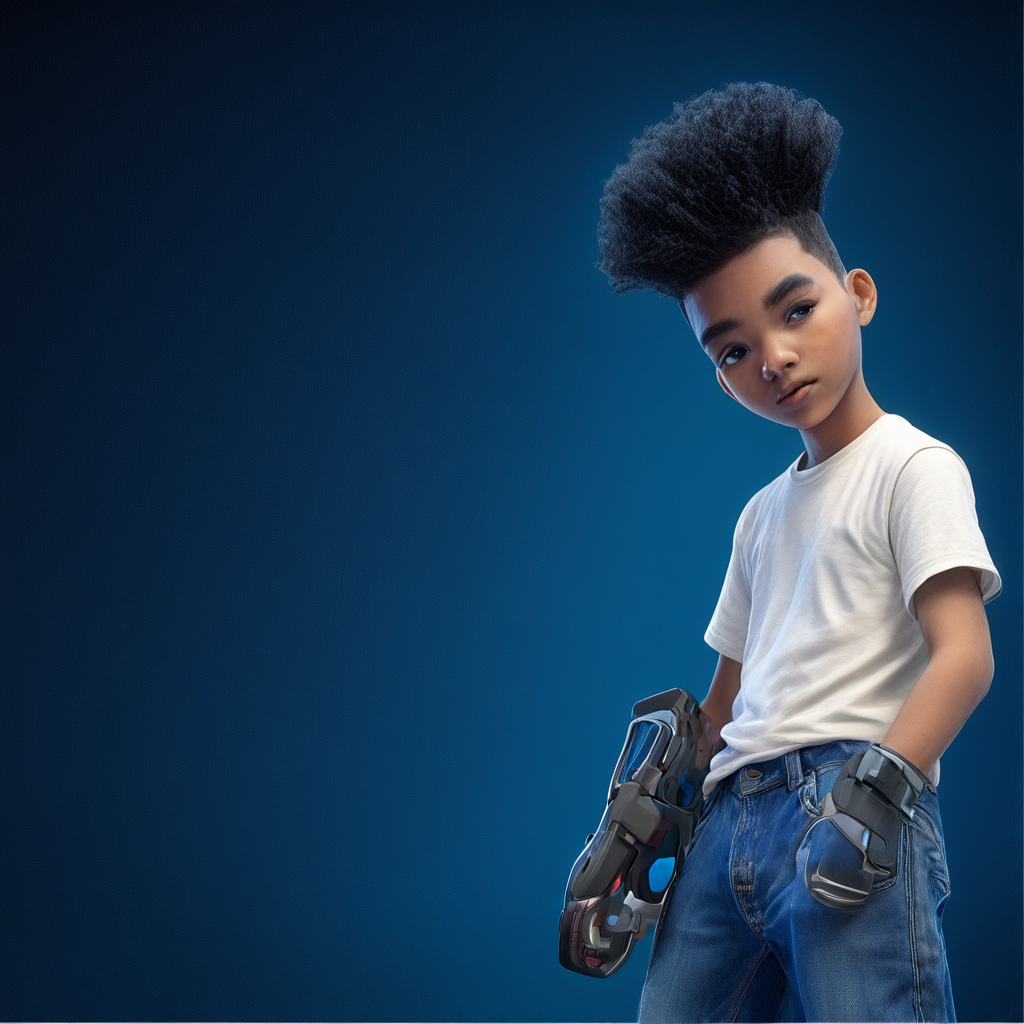

In [3]:
import torch
from diffusers import BriaPipeline
from IPython.display import display
from PIL import Image

# Load the Bria 3.2 model
# trust_remote_code = True allows loading a transformer which is not present in the transformers library
pipe = BriaPipeline.from_pretrained("briaai/BRIA-3.2", torch_dtype=torch.bfloat16)

# Load your trained LoRA weights
pipe.load_lora_weights("example_output_lora/", weight_name="pytorch_lora_weights.safetensors")

# Move the model to GPU
pipe.to(device="cuda")

# Set up prompts
prompt = "Stylized 3D, exaggerated proportions, vibrant gaming character with a young boy wearing a blue jeans and white t-shirt"
negative_prompt = "Logo,Watermark,Text,Ugly,Morbid,Extra fingers,Poorly drawn hands,Mutation,Blurry,Extra limbs,Gross proportions,Missing arms,Mutated hands,Long neck,Duplicate,Mutilated,Mutilated hands,Poorly drawn face,Deformed,Bad anatomy,Cloned face,Malformed limbs,Missing legs,Too many fingers"

# Set seed for reproducibility
seed = 42
lora_scale = 1.0  # You can adjust this to control the influence of your LoRA
generator = torch.Generator("cuda").manual_seed(seed)

# Generate the image
image = pipe(
    prompt=prompt, 
    negative_prompt=negative_prompt, 
    height=1024, 
    width=1024, 
    generator=generator, 
    joint_attention_kwargs={"scale": lora_scale},
    num_inference_steps=30,  # Recommended: 30-50 steps
    guidance_scale=5.0      # Recommended: 5.0
).images[0]

# Display the generated image
display(image)

# Save the image
image.save("generated_image.png")

## Generation Tips and Recommendations

Here are some tips for generating the best images with your fine-tuned model:

1. **Prompt Engineering**:
   - Include your trigger word or consistent description
   - Be descriptive but concise
   - Experiment with different prompts to see what works best

2. **Negative Prompts**:
   - Using negative prompts can help avoid common issues
   - The example negative prompt helps prevent common problems like extra fingers, watermarks, etc.

3. **Resolution and Aspect Ratio**:
   - The model supports multiple aspect ratios
   - Total resolution should be approximately 1M pixels (e.g., 1024×1024)
   - Supported resolutions include: (1024,1024), (1280, 768), (1344, 768), (832, 1216), etc.

4. **Generation Parameters**:
   - Use 30-50 inference steps for better quality (higher is better)
   - Use a guidance_scale of 5.0
   - Adjust lora_scale to control the influence of your fine-tuning (0.7-1.0 is a good range)

5. **Seed**:
   - Use fixed seeds for reproducible results
   - Try different seeds to get varied outputs

## Batch Generation

Let's create a function to generate multiple images with different prompts or seeds:

In [1]:
def generate_batch(prompts, seeds, lora_scale=1.0, height=1024, width=1024):
    """Generate multiple images with different prompts and seeds"""
    results = []
    
    negative_prompt = "Logo,Watermark,Text,Ugly,Morbid,Extra fingers,Poorly drawn hands,Mutation,Blurry,Extra limbs,Gross proportions,Missing arms,Mutated hands,Long neck,Duplicate,Mutilated,Mutilated hands,Poorly drawn face,Deformed,Bad anatomy,Cloned face,Malformed limbs,Missing legs,Too many fingers"
    
    for i, (prompt, seed) in enumerate(zip(prompts, seeds)):
        print(f"Generating image {i+1}/{len(prompts)}...")
        generator = torch.Generator("cuda").manual_seed(seed)
        
        image = pipe(
            prompt=prompt, 
            negative_prompt=negative_prompt, 
            height=height, 
            width=width, 
            generator=generator, 
            joint_attention_kwargs={"scale": lora_scale},
            num_inference_steps=30,
            guidance_scale=5.0
        ).images[0]
        
        results.append((image, prompt, seed))
        
    return results

# Example usage
prompts = ["Stylized 3D, exaggerated proportions, vibrant gaming character with a young boy wearing a red cap and a blue shirt and short green pants",
           "Stylized 3D, exaggerated proportions, vibrant gaming character with a young boy wearing an orange jumpsuit",
           "Stylized 3D, exaggerated proportions, vibrant gaming character with a young boy wearing a colorfull clown costume",
           
           ]

seeds = [42,43,44]

# Generate the batch of images
results = generate_batch(prompts, seeds)

# Display and save the results
for i, (image, prompt, seed) in enumerate(results):
    print(f"Image {i+1}")
    print(f"Prompt: {prompt}")
    print(f"Seed: {seed}")
    display(image)
    image.save(f"generated_image_{i+1}.png")
    print("\n")

Generating image 1/1...


NameError: name 'torch' is not defined

## Experimenting with Different Aspect Ratios

Bria 3.2 supports various aspect ratios. Let's try generating images with different dimensions:

In [ ]:
# Different aspect ratios to try
aspect_ratios = [
    (1024, 1024),  # 1:1 square
    (1280, 768),   # 5:3 landscape
    (832, 1216)    # 2:3 portrait
]

prompt = "An illustration of a character named Briabear, a cute brown bear, standing in a meadow with flowers."
seed = 42

# Generate images with different aspect ratios
for i, (width, height) in enumerate(aspect_ratios):
    print(f"Generating image with dimensions {width}x{height}...")
    generator = torch.Generator("cuda").manual_seed(seed)
    
    image = pipe(
        prompt=prompt, 
        negative_prompt=negative_prompt, 
        height=height, 
        width=width, 
        generator=generator, 
        joint_attention_kwargs={"scale": lora_scale},
        num_inference_steps=30,
        guidance_scale=5.0
    ).images[0]
    
    print(f"Aspect ratio: {width}x{height}")
    display(image)
    image.save(f"generated_image_aspect_{width}x{height}.png")
    print("\n")

## Experimenting with LoRA Scale

The LoRA scale parameter controls how strongly your fine-tuned model influences the generation. Let's experiment with different values:

In [ ]:
# Different LoRA scales to try
lora_scales = [0.5, 0.75, 1.0, 1.25]

prompt = "An illustration of a character named Briabear, a cute brown bear, sitting at a cafe table drinking coffee."
seed = 42

# Generate images with different LoRA scales
for i, scale in enumerate(lora_scales):
    print(f"Generating image with LoRA scale {scale}...")
    generator = torch.Generator("cuda").manual_seed(seed)
    
    image = pipe(
        prompt=prompt, 
        negative_prompt=negative_prompt, 
        height=1024, 
        width=1024, 
        generator=generator, 
        joint_attention_kwargs={"scale": scale},
        num_inference_steps=30,
        guidance_scale=5.0
    ).images[0]
    
    print(f"LoRA scale: {scale}")
    display(image)
    image.save(f"generated_image_lora_scale_{scale}.png")
    print("\n")

## Conclusion

In this notebook, we've explored Bria 3.2, a text-to-image model specifically designed for fine-tuning and commercial use. We've covered:

1. **Setting up the environment** and installing the necessary dependencies
2. **Preparing data** for fine-tuning
3. **Training a LoRA model** on custom data
4. **Generating images** with the fine-tuned model
5. **Experimenting with different parameters** like aspect ratios and LoRA scale

Bria 3.2 is particularly well-suited for commercial applications because it's built on fully licensed data and comes with legal liability coverage. This makes it an excellent choice for businesses looking to create custom visuals while ensuring copyright compliance.

### Next Steps

- Try fine-tuning on your own custom datasets
- Experiment with different prompts and parameters
- Consider integrating the model into your applications or workflows

For more information, visit the [BRIA AI website](https://bria.ai) or join their [Discord community](https://discord.gg/briaai) for tutorials, tools, and to connect with other users.